# 📊 e스포츠 vs 전통 스포츠 시장 비교 분석

## 📌 프로젝트 정보
- **대주제**: e스포츠는 스포츠인가? - 데이터로 검증하는 e스포츠의 스포츠적 가치
- **소주제**: e스포츠 vs 전통 스포츠 시장 규모 및 성장성 비교
- **담당자**: 팀원 B

## 🎯 분석 목표
1. 글로벌 스포츠 시장 규모 비교 (축구, NBA, NFL, e스포츠)
2. 연도별 시장 성장률 비교
3. 시청자 수 및 팬덤 규모 비교
4. 스폰서십 및 중계권료 비교
5. 한국 내 스포츠 시장 점유율 분석

## 📊 사용할 시각화
- 그룹 바 차트 (Grouped Bar Chart)
- 다중 라인 차트 (Multiple Line Chart)
- 버블 차트 (Bubble Chart)
- 파이 차트 (Pie Chart)

---
## 1. 라이브러리 임포트 및 환경 설정

In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 크롤링 라이브러리
import requests
from bs4 import BeautifulSoup

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')  # Windows
# plt.rc('font', family='AppleGothic')  # Mac
plt.rcParams['axes.unicode_minus'] = False

# 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


---
## 2. 데이터 수집

### 2-1. 글로벌 스포츠 시장 규모 데이터

In [2]:
# 글로벌 스포츠 시장 규모 (2023년 기준, 단위: 10억 달러)
market_size_data = {
    'Sport': ['축구 (글로벌)', 'NFL (미식축구)', 'NBA (농구)', 'MLB (야구)', 'F1', 'e스포츠', 'UFC', '테니스'],
    'Market_Size_2023': [30.0, 18.6, 10.6, 10.3, 3.2, 1.87, 1.3, 1.2],
    'Market_Size_2019': [25.0, 15.0, 8.8, 9.5, 2.0, 0.95, 0.9, 1.0],
    'Projected_2028': [42.0, 25.0, 15.0, 12.0, 5.0, 5.48, 2.5, 1.8],
    'CAGR_Percent': [5.5, 6.0, 7.0, 3.5, 9.0, 21.0, 12.0, 6.5],
    'Category': ['전통 스포츠', '전통 스포츠', '전통 스포츠', '전통 스포츠', '모터 스포츠', 'e스포츠', '격투기', '전통 스포츠']
}

df_market = pd.DataFrame(market_size_data)
df_market = df_market.sort_values('Market_Size_2023', ascending=False)
df_market

,Sport,Market_Size_2023,Market_Size_2019,Projected_2028,CAGR_Percent,Category
0,축구 (글로벌),30.00,25.00,42.00,5.5,전통 스포츠
1,NFL (미식축구),18.60,15.00,25.00,6.0,전통 스포츠
2,NBA (농구),10.60,8.80,15.00,7.0,전통 스포츠
3,MLB (야구),10.30,9.50,12.00,3.5,전통 스포츠
4,F1,3.20,2.00,5.00,9.0,모터 스포츠
5,e스포츠,1.87,0.95,5.48,21.0,e스포츠
6,UFC,1.30,0.90,2.50,12.0,격투기
7,테니스,1.20,1.00,1.80,6.5,전통 스포츠


### 2-2. 연도별 시장 규모 추이

In [3]:
# 연도별 시장 규모 추이 (2018-2028 예상)
years = list(range(2018, 2029))

market_trend = {
    'Year': years,
    'e스포츠': [0.78, 0.95, 0.97, 1.08, 1.38, 1.87, 2.21, 2.89, 3.54, 4.32, 5.48],
    'NBA': [7.8, 8.8, 8.3, 8.0, 9.5, 10.6, 11.5, 12.5, 13.5, 14.2, 15.0],
    'NFL': [13.0, 15.0, 12.5, 11.0, 16.5, 18.6, 20.0, 21.5, 23.0, 24.0, 25.0],
    'MLB': [9.0, 9.5, 9.0, 8.5, 10.0, 10.3, 10.8, 11.0, 11.4, 11.7, 12.0],
    '축구(글로벌)': [22.0, 25.0, 24.0, 22.0, 27.0, 30.0, 32.0, 35.0, 38.0, 40.0, 42.0]
}

df_trend = pd.DataFrame(market_trend)
df_trend

,Year,e스포츠,NBA,NFL,MLB,축구(글로벌)
0,2018,0.78,7.8,13.0,9.0,22.0
1,2019,0.95,8.8,15.0,9.5,25.0
2,2020,0.97,8.3,12.5,9.0,24.0
3,2021,1.08,8.0,11.0,8.5,22.0
4,2022,1.38,9.5,16.5,10.0,27.0
5,2023,1.87,10.6,18.6,10.3,30.0
6,2024,2.21,11.5,20.0,10.8,32.0
7,2025,2.89,12.5,21.5,11.0,35.0
8,2026,3.54,13.5,23.0,11.4,38.0
9,2027,4.32,14.2,24.0,11.7,40.0


### 2-3. 시청자 수 비교 데이터

In [4]:
# 주요 스포츠 이벤트 시청자 수 (단위: 백만 명)
viewership_data = {
    'Event': ['FIFA 월드컵 결승', '슈퍼볼', 'NBA 파이널', 'LoL 월드컵 결승', 'MLB 월드시리즈', 'UEFA 챔스 결승', 'Dota2 TI 결승'],
    'Peak_Viewers_Million': [1500, 115, 50, 6.4, 14, 450, 2.7],
    'Unique_Viewers_Million': [3200, 200, 100, 75, 40, 700, 30],
    'Year': [2022, 2024, 2024, 2024, 2023, 2024, 2023],
    'Type': ['전통 스포츠', '전통 스포츠', '전통 스포츠', 'e스포츠', '전통 스포츠', '전통 스포츠', 'e스포츠'],
    'Online_Percent': [35, 25, 30, 98, 20, 40, 100]
}

df_viewership = pd.DataFrame(viewership_data)
df_viewership

,Event,Peak_Viewers_Million,Unique_Viewers_Million,Year,Type,Online_Percent
0,FIFA 월드컵 결승,1500.0,3200,2022,전통 스포츠,35
1,슈퍼볼,115.0,200,2024,전통 스포츠,25
2,NBA 파이널,50.0,100,2024,전통 스포츠,30
3,LoL 월드컵 결승,6.4,75,2024,e스포츠,98
4,MLB 월드시리즈,14.0,40,2023,전통 스포츠,20
5,UEFA 챔스 결승,450.0,700,2024,전통 스포츠,40
6,Dota2 TI 결승,2.7,30,2023,e스포츠,100


### 2-4. 스폰서십 및 중계권료 데이터

In [5]:
# 스폰서십 규모 (연간, 단위: 백만 달러)
sponsorship_data = {
    'League': ['EPL (축구)', 'NFL', 'NBA', 'MLB', 'LCK (LoL)', 'LCS (LoL)', 'VALORANT Champions'],
    'Sponsorship_Annual': [2500, 1800, 1500, 900, 150, 120, 100],
    'Media_Rights_Annual': [3000, 10000, 2600, 1800, 50, 40, 30],
    'Total_Revenue': [5500, 11800, 4100, 2700, 200, 160, 130],
    'Type': ['전통 스포츠', '전통 스포츠', '전통 스포츠', '전통 스포츠', 'e스포츠', 'e스포츠', 'e스포츠'],
    'Growth_Rate': [5, 4, 8, 3, 25, 20, 35]
}

df_sponsorship = pd.DataFrame(sponsorship_data)
df_sponsorship

,League,Sponsorship_Annual,Media_Rights_Annual,Total_Revenue,Type,Growth_Rate
0,EPL (축구),2500,3000,5500,전통 스포츠,5
1,NFL,1800,10000,11800,전통 스포츠,4
2,NBA,1500,2600,4100,전통 스포츠,8
3,MLB,900,1800,2700,전통 스포츠,3
4,LCK (LoL),150,50,200,e스포츠,25
5,LCS (LoL),120,40,160,e스포츠,20
6,VALORANT Champions,100,30,130,e스포츠,35


### 2-5. 한국 스포츠 시장 데이터

In [6]:
# 한국 스포츠 시장 규모 (2023년, 단위: 억 원)
korea_market = {
    'Sport': ['프로야구 (KBO)', '프로축구 (K리그)', '프로농구 (KBL)', '프로배구 (V리그)', 'e스포츠', '골프', '기타'],
    'Market_Size_KRW': [8500, 3200, 1800, 1500, 2500, 5000, 3000],
    'Attendance_Thousand': [8200, 3500, 1200, 800, 500, 0, 0],
    'Online_Viewers_Million': [50, 30, 10, 8, 120, 5, 10],
    'Avg_Age_Viewer': [42, 38, 35, 32, 24, 45, 40],
    'Growth_2023': [8, 5, 3, 2, 18, 10, 5]
}

df_korea = pd.DataFrame(korea_market)
df_korea['Total_Market'] = df_korea['Market_Size_KRW'].sum()
df_korea['Market_Share'] = df_korea['Market_Size_KRW'] / df_korea['Total_Market'] * 100
df_korea

,Sport,Market_Size_KRW,Attendance_Thousand,Online_Viewers_Million,Avg_Age_Viewer,Growth_2023,Total_Market,Market_Share
0,프로야구 (KBO),8500,8200,50,42,8,25500,33.333333
1,프로축구 (K리그),3200,3500,30,38,5,25500,12.549020
2,프로농구 (KBL),1800,1200,10,35,3,25500,7.058824
3,프로배구 (V리그),1500,800,8,32,2,25500,5.882353
4,e스포츠,2500,500,120,24,18,25500,9.803922
5,골프,5000,0,5,45,10,25500,19.607843
6,기타,3000,0,10,40,5,25500,11.764706


### 2-6. 연령별 스포츠 선호도

In [7]:
# 연령별 스포츠 선호도 (시청 비율 %)
age_preference = {
    'Age_Group': ['10대', '20대', '30대', '40대', '50대 이상'],
    'e스포츠': [45, 40, 20, 8, 3],
    '프로야구': [15, 25, 35, 40, 45],
    '프로축구': [20, 30, 30, 35, 30],
    '프로농구': [15, 20, 15, 10, 8],
    'UFC/격투기': [10, 15, 12, 8, 5]
}

df_age = pd.DataFrame(age_preference)
df_age

,Age_Group,e스포츠,프로야구,프로축구,프로농구,UFC/격투기
0,10대,45,15,20,15,10
1,20대,40,25,30,20,15
2,30대,20,35,30,15,12
3,40대,8,40,35,10,8
4,50대 이상,3,45,30,8,5


---
## 3. 데이터 전처리

In [8]:
# 성장률 계산
df_market['Growth_2019_2023'] = ((df_market['Market_Size_2023'] / df_market['Market_Size_2019']) - 1) * 100
print("=== 2019-2023 시장 성장률 ===")
print(df_market[['Sport', 'Growth_2019_2023']].sort_values('Growth_2019_2023', ascending=False))

=== 2019-2023 시장 성장률 ===
        Sport  Growth_2019_2023
5        e스포츠         96.842105
4          F1         60.000000
6         UFC         44.444444
1  NFL (미식축구)         24.000000
2    NBA (농구)         20.454545
0    축구 (글로벌)         20.000000
7         테니스         20.000000
3    MLB (야구)          8.421053


In [9]:
# e스포츠 vs 전통 스포츠 평균 비교
esports = df_market[df_market['Category'] == 'e스포츠']
traditional = df_market[df_market['Category'] == '전통 스포츠']

print("\n=== 카테고리별 평균 성장률 ===")
print(f"e스포츠 CAGR: {esports['CAGR_Percent'].mean():.1f}%")
print(f"전통 스포츠 CAGR: {traditional['CAGR_Percent'].mean():.1f}%")


=== 카테고리별 평균 성장률 ===
e스포츠 CAGR: 21.0%
전통 스포츠 CAGR: 5.7%


---
## 4. 데이터 시각화

### 4-1. 글로벌 스포츠 시장 규모 비교

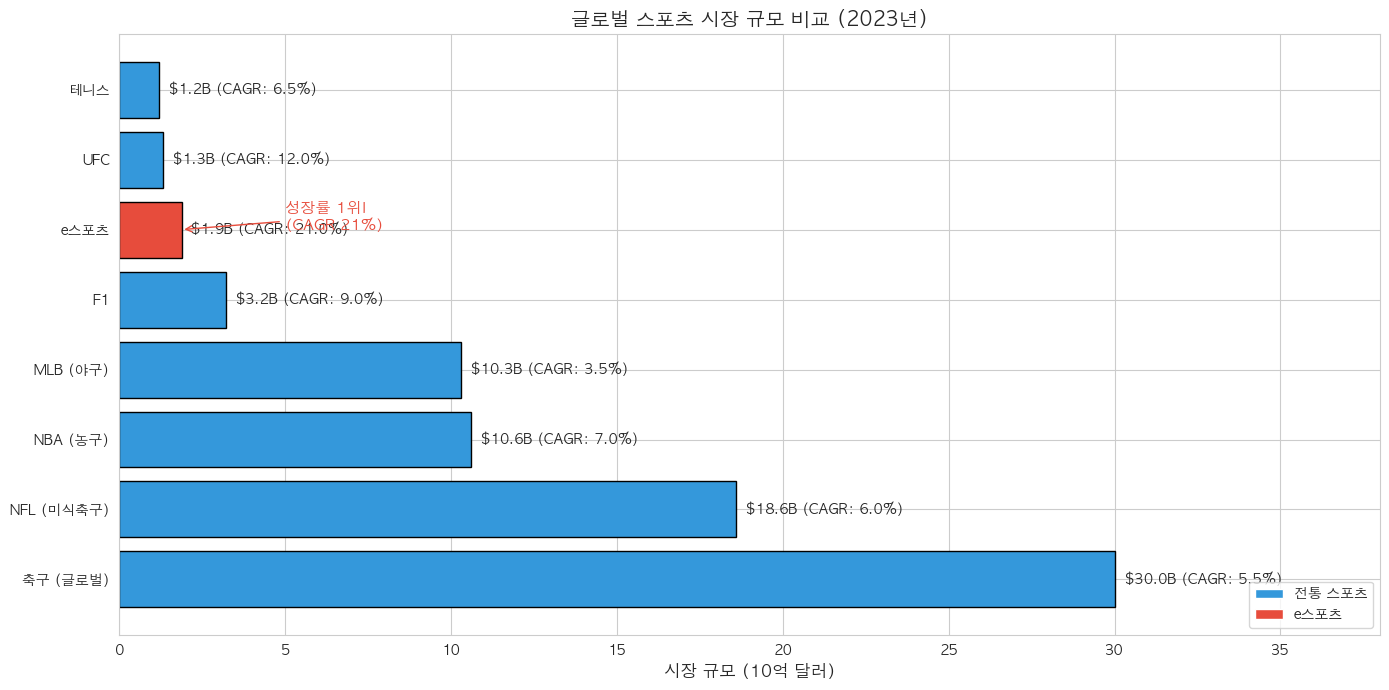

In [10]:
plt.rc('font', family='AppleGothic')  # Mac

fig, ax = plt.subplots(figsize=(14, 7))

# 색상 설정
colors = ['#E74C3C' if cat == 'e스포츠' else '#3498DB' for cat in df_market['Category']]

bars = ax.barh(df_market['Sport'], df_market['Market_Size_2023'], color=colors, edgecolor='black')

# 값 표시
for bar, val, growth in zip(bars, df_market['Market_Size_2023'], df_market['CAGR_Percent']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'${val:.1f}B (CAGR: {growth}%)', va='center', fontsize=10)

ax.set_xlabel('시장 규모 (10억 달러)', fontsize=12)
ax.set_title('글로벌 스포츠 시장 규모 비교 (2023년)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 38)

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498DB', label='전통 스포츠'),
                   Patch(facecolor='#E74C3C', label='e스포츠')]
ax.legend(handles=legend_elements, loc='lower right')

# e스포츠 강조
ax.annotate('성장률 1위!\n(CAGR 21%)', xy=(1.87, 5), xytext=(5, 5),
            fontsize=11, color='#E74C3C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'))

plt.tight_layout()
plt.savefig('global_market_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-2. 시장 성장률 추이 비교 (라인 차트)

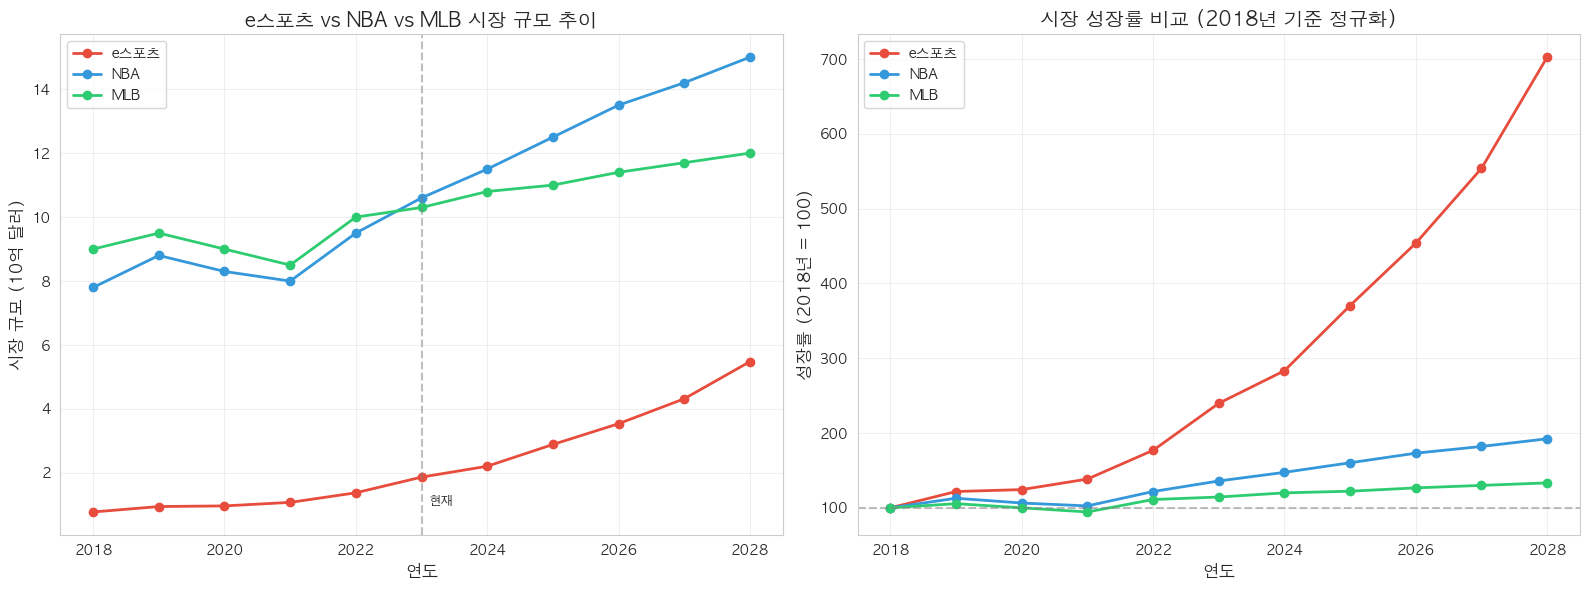

In [11]:
plt.rc('font', family='AppleGothic')  # Mac

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 절대 규모 비교
sports_to_plot = ['e스포츠', 'NBA', 'MLB']
colors = {'e스포츠': '#E74C3C', 'NBA': '#3498DB', 'MLB': '#2ECC71'}

for sport in sports_to_plot:
    axes[0].plot(df_trend['Year'], df_trend[sport], marker='o', linewidth=2, 
                 label=sport, color=colors[sport])

axes[0].set_xlabel('연도', fontsize=12)
axes[0].set_ylabel('시장 규모 (10억 달러)', fontsize=12)
axes[0].set_title('e스포츠 vs NBA vs MLB 시장 규모 추이', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=2023, color='gray', linestyle='--', alpha=0.5)
axes[0].text(2023.1, 1, '현재', fontsize=9)

# 오른쪽: 성장률 비교 (2018년 = 100 기준)
for sport in sports_to_plot:
    normalized = [v / df_trend[sport].iloc[0] * 100 for v in df_trend[sport]]
    axes[1].plot(df_trend['Year'], normalized, marker='o', linewidth=2, 
                 label=sport, color=colors[sport])

axes[1].set_xlabel('연도', fontsize=12)
axes[1].set_ylabel('성장률 (2018년 = 100)', fontsize=12)
axes[1].set_title('시장 성장률 비교 (2018년 기준 정규화)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=100, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('market_growth_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-3. 시청자 수 비교 (버블 차트)

In [12]:
plt.rc('font', family='AppleGothic')  # Mac

fig = px.scatter(
    df_viewership,
    x='Peak_Viewers_Million',
    y='Online_Percent',
    size='Unique_Viewers_Million',
    color='Type',
    hover_name='Event',
    text='Event',
    color_discrete_map={'전통 스포츠': '#3498DB', 'e스포츠': '#E74C3C'},
    title='스포츠 이벤트 시청자 분석: 최대 동시 시청자 vs 온라인 시청 비율'
)

fig.update_traces(textposition='top center', textfont_size=10)
fig.update_layout(
    xaxis_title='최대 동시 시청자 (백만 명, 로그 스케일)',
    yaxis_title='온라인 시청 비율 (%)',
    xaxis_type='log',
    showlegend=True
)

fig.show()

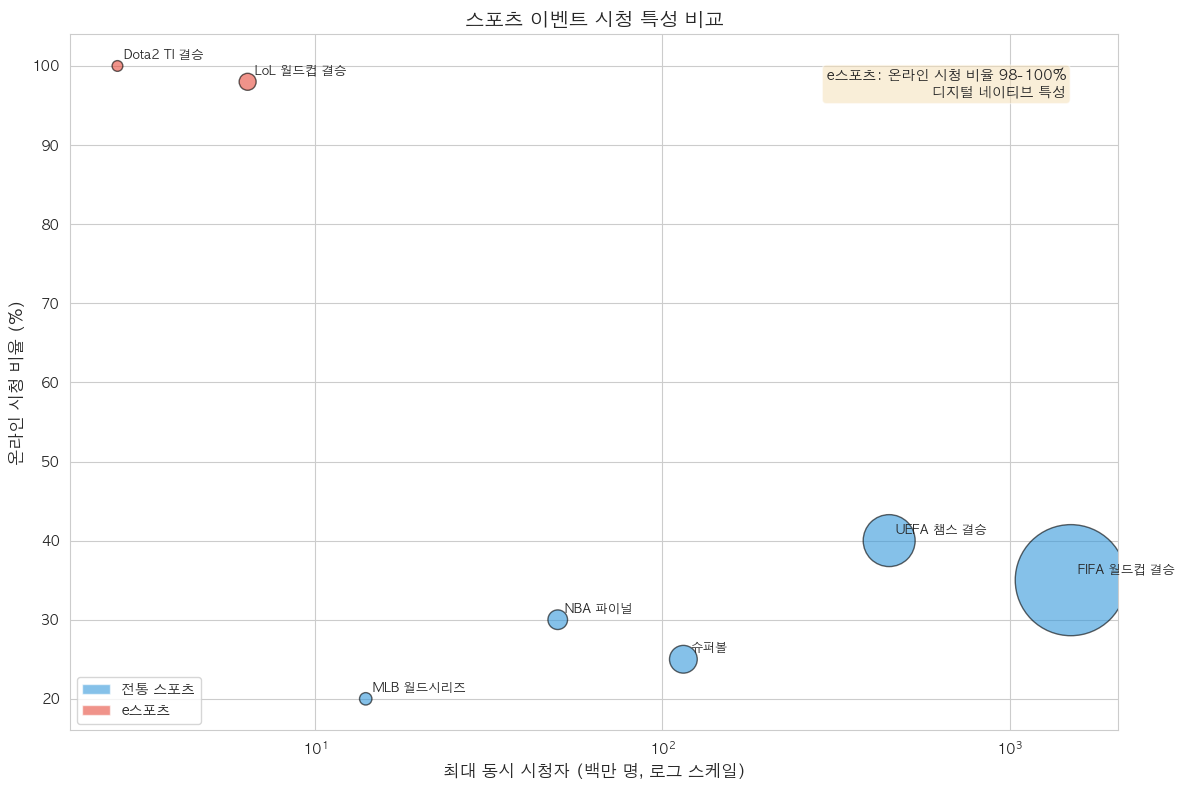

In [13]:
plt.rc('font', family='AppleGothic')  # Mac

# 정적 버전
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#E74C3C' if t == 'e스포츠' else '#3498DB' for t in df_viewership['Type']]
sizes = df_viewership['Unique_Viewers_Million'] * 2

scatter = ax.scatter(df_viewership['Peak_Viewers_Million'], df_viewership['Online_Percent'],
                     s=sizes, c=colors, alpha=0.6, edgecolors='black')

# 이벤트 이름 표시
for _, row in df_viewership.iterrows():
    ax.annotate(row['Event'], (row['Peak_Viewers_Million'], row['Online_Percent']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xscale('log')
ax.set_xlabel('최대 동시 시청자 (백만 명, 로그 스케일)', fontsize=12)
ax.set_ylabel('온라인 시청 비율 (%)', fontsize=12)
ax.set_title('스포츠 이벤트 시청 특성 비교', fontsize=14, fontweight='bold')

# 범례
legend_elements = [Patch(facecolor='#3498DB', alpha=0.6, label='전통 스포츠'),
                   Patch(facecolor='#E74C3C', alpha=0.6, label='e스포츠')]
ax.legend(handles=legend_elements, loc='lower left')

# 인사이트 박스
ax.text(0.95, 0.95, 'e스포츠: 온라인 시청 비율 98-100%\n디지털 네이티브 특성', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('viewership_bubble.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-4. 스폰서십 및 중계권료 비교

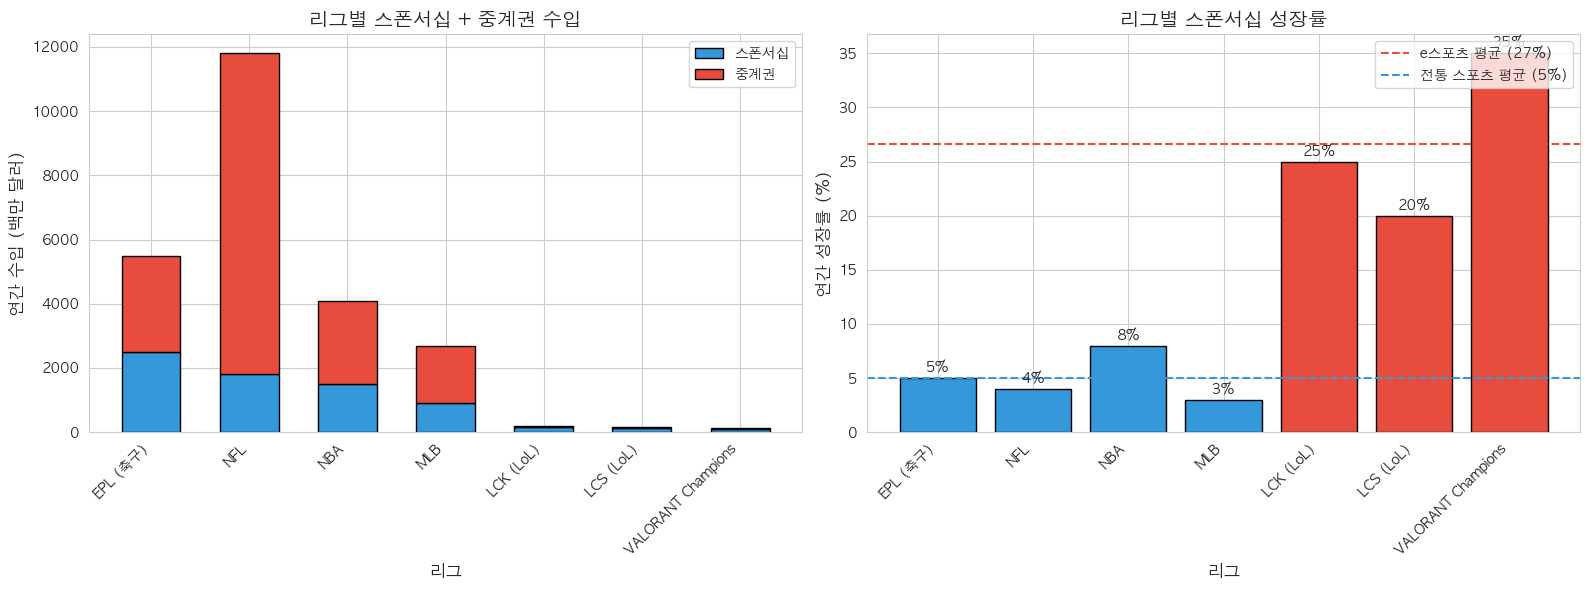

In [14]:
plt.rc('font', family='AppleGothic')  # Mac

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 수입 구조 비교 (스택 바)
x = np.arange(len(df_sponsorship))
width = 0.6

colors_type = ['#E74C3C' if t == 'e스포츠' else '#3498DB' for t in df_sponsorship['Type']]

axes[0].bar(x, df_sponsorship['Sponsorship_Annual'], width, label='스폰서십', color='#3498DB', edgecolor='black')
axes[0].bar(x, df_sponsorship['Media_Rights_Annual'], width, bottom=df_sponsorship['Sponsorship_Annual'],
            label='중계권', color='#E74C3C', edgecolor='black')

axes[0].set_xlabel('리그', fontsize=12)
axes[0].set_ylabel('연간 수입 (백만 달러)', fontsize=12)
axes[0].set_title('리그별 스폰서십 + 중계권 수입', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_sponsorship['League'], rotation=45, ha='right')
axes[0].legend()

# 오른쪽: 성장률 비교
colors_growth = ['#E74C3C' if t == 'e스포츠' else '#3498DB' for t in df_sponsorship['Type']]
bars = axes[1].bar(df_sponsorship['League'], df_sponsorship['Growth_Rate'], color=colors_growth, edgecolor='black')

for bar, val in zip(bars, df_sponsorship['Growth_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val}%', ha='center', fontsize=10)

axes[1].set_xlabel('리그', fontsize=12)
axes[1].set_ylabel('연간 성장률 (%)', fontsize=12)
axes[1].set_title('리그별 스폰서십 성장률', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(df_sponsorship['League'], rotation=45, ha='right')

# 평균선
esports_growth = df_sponsorship[df_sponsorship['Type'] == 'e스포츠']['Growth_Rate'].mean()
trad_growth = df_sponsorship[df_sponsorship['Type'] == '전통 스포츠']['Growth_Rate'].mean()
axes[1].axhline(y=esports_growth, color='#E74C3C', linestyle='--', label=f'e스포츠 평균 ({esports_growth:.0f}%)')
axes[1].axhline(y=trad_growth, color='#3498DB', linestyle='--', label=f'전통 스포츠 평균 ({trad_growth:.0f}%)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('sponsorship_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-5. 한국 스포츠 시장 점유율

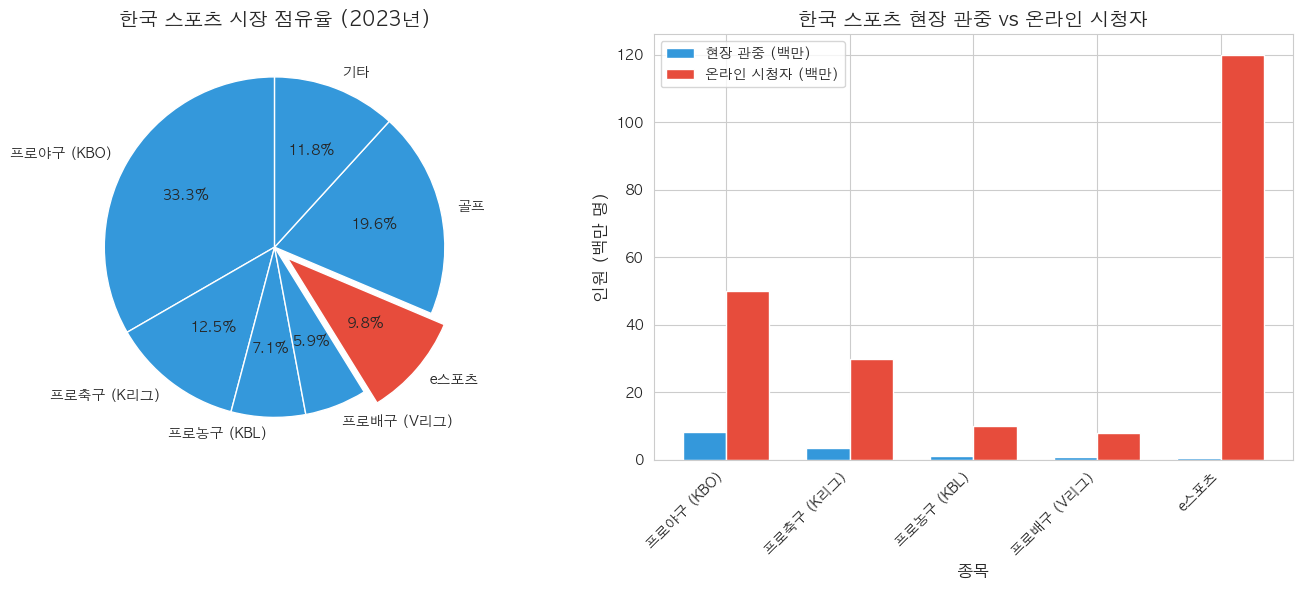

In [15]:
plt.rc('font', family='AppleGothic')  # Mac

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 시장 점유율 파이 차트
colors = ['#E74C3C' if s == 'e스포츠' else '#3498DB' for s in df_korea['Sport']]
explode = [0.1 if s == 'e스포츠' else 0 for s in df_korea['Sport']]

axes[0].pie(df_korea['Market_Size_KRW'], labels=df_korea['Sport'], autopct='%1.1f%%',
            colors=colors, explode=explode, startangle=90, textprops={'fontsize': 10})
axes[0].set_title('한국 스포츠 시장 점유율 (2023년)', fontsize=14, fontweight='bold')

# 오른쪽: 온라인 시청자 vs 현장 관중
x = np.arange(len(df_korea) - 2)  # 골프, 기타 제외
width = 0.35

df_korea_filtered = df_korea[df_korea['Attendance_Thousand'] > 0]

axes[1].bar(x - width/2, df_korea_filtered['Attendance_Thousand']/1000, width, 
            label='현장 관중 (백만)', color='#3498DB')
axes[1].bar(x + width/2, df_korea_filtered['Online_Viewers_Million'], width, 
            label='온라인 시청자 (백만)', color='#E74C3C')

axes[1].set_xlabel('종목', fontsize=12)
axes[1].set_ylabel('인원 (백만 명)', fontsize=12)
axes[1].set_title('한국 스포츠 현장 관중 vs 온라인 시청자', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_korea_filtered['Sport'], rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('korea_market.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-6. 연령별 스포츠 선호도 (히트맵)

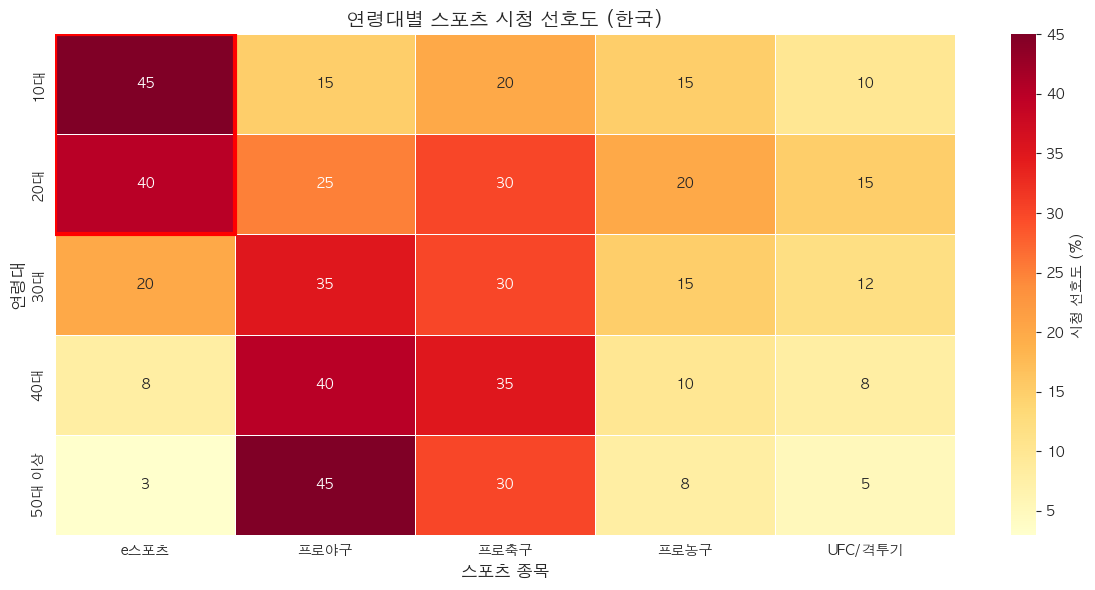

In [16]:
plt.rc('font', family='AppleGothic')  # Mac

fig, ax = plt.subplots(figsize=(12, 6))

# 히트맵 데이터 준비
heatmap_df = df_age.set_index('Age_Group')

sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': '시청 선호도 (%)'})

ax.set_title('연령대별 스포츠 시청 선호도 (한국)', fontsize=14, fontweight='bold')
ax.set_xlabel('스포츠 종목', fontsize=12)
ax.set_ylabel('연령대', fontsize=12)

# e스포츠 하이라이트 박스
ax.add_patch(plt.Rectangle((0, 0), 1, 2, fill=False, edgecolor='red', linewidth=3))

plt.tight_layout()
plt.savefig('age_preference_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-7. 성장률 vs 시장 규모 사분면 분석

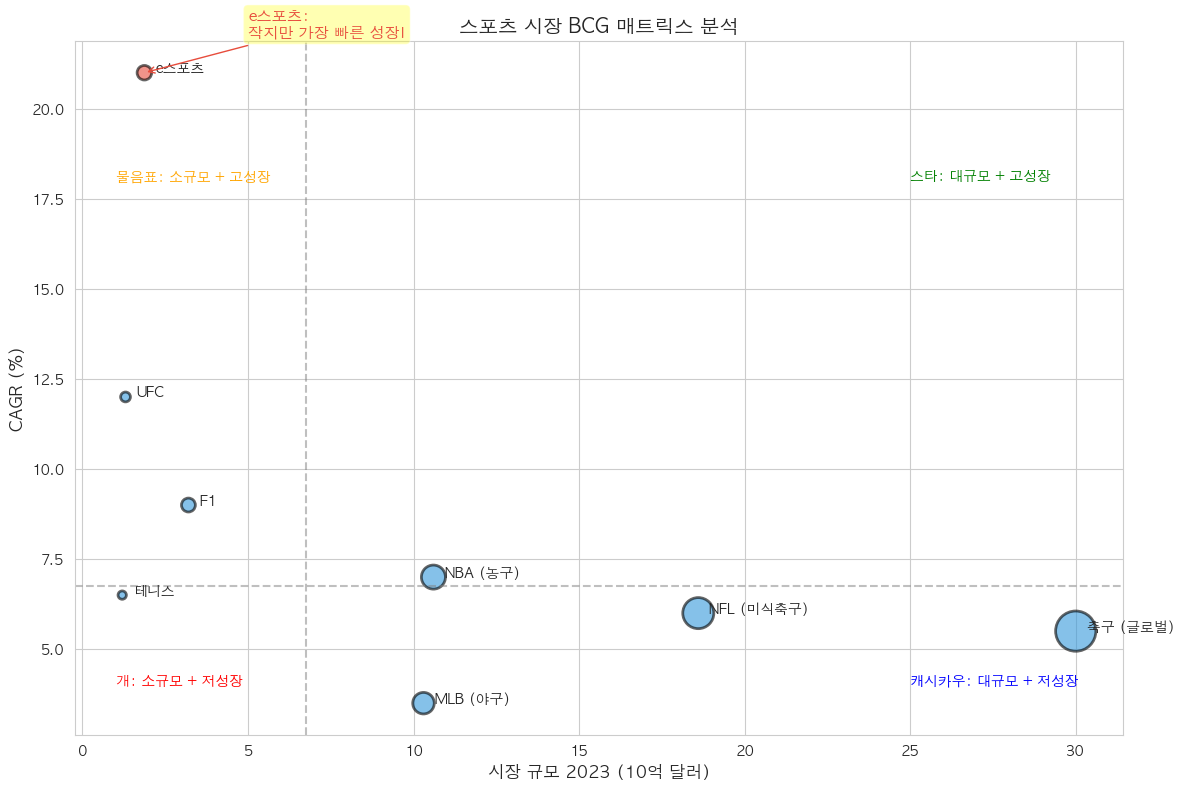

In [17]:
plt.rc('font', family='AppleGothic')  # Mac

fig, ax = plt.subplots(figsize=(12, 8))

# 버블 차트
colors = ['#E74C3C' if cat == 'e스포츠' else '#3498DB' for cat in df_market['Category']]
sizes = df_market['Projected_2028'] * 20

scatter = ax.scatter(df_market['Market_Size_2023'], df_market['CAGR_Percent'],
                     s=sizes, c=colors, alpha=0.6, edgecolors='black', linewidths=2)

# 스포츠 이름 표시
for _, row in df_market.iterrows():
    ax.annotate(row['Sport'], (row['Market_Size_2023'], row['CAGR_Percent']),
                xytext=(8, 0), textcoords='offset points', fontsize=10)

# 평균선 (사분면 구분)
ax.axvline(x=df_market['Market_Size_2023'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=df_market['CAGR_Percent'].median(), color='gray', linestyle='--', alpha=0.5)

# 사분면 라벨
ax.text(25, 18, '스타: 대규모 + 고성장', fontsize=10, color='green', fontweight='bold')
ax.text(1, 18, '물음표: 소규모 + 고성장', fontsize=10, color='orange', fontweight='bold')
ax.text(25, 4, '캐시카우: 대규모 + 저성장', fontsize=10, color='blue', fontweight='bold')
ax.text(1, 4, '개: 소규모 + 저성장', fontsize=10, color='red', fontweight='bold')

ax.set_xlabel('시장 규모 2023 (10억 달러)', fontsize=12)
ax.set_ylabel('CAGR (%)', fontsize=12)
ax.set_title('스포츠 시장 BCG 매트릭스 분석', fontsize=14, fontweight='bold')

# e스포츠 특별 강조
ax.annotate('e스포츠:\n작지만 가장 빠른 성장!', xy=(1.87, 21), xytext=(5, 22),
            fontsize=11, color='#E74C3C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'),
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('bcg_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. 결론 및 인사이트

### 📊 분석 결과

1. **시장 규모 현황**
   - e스포츠 글로벌 시장: 2023년 기준 약 18.7억 달러 (약 2.5조 원)
   - 전통 스포츠 대비 규모는 작음 (NFL의 1/10, 축구의 1/16)
   - **BUT**: 성장률은 압도적 1위 (CAGR 21% vs 전통 스포츠 평균 5%)

2. **성장 잠재력**
   - 2028년 예상 시장 규모: 54.8억 달러 (약 3배 성장)
   - 같은 기간 NFL은 1.3배, NBA는 1.4배 성장 예상
   - BCG 매트릭스 상 "물음표" → "스타" 이동 가능성

3. **시청자 특성**
   - 절대 시청자 수: 전통 스포츠 우위 (월드컵 15억 vs 롤드컵 0.75억)
   - 온라인 시청 비율: e스포츠 98-100% vs 전통 스포츠 20-40%
   - 디지털 네이티브 세대의 "스포츠" 정의 변화

4. **한국 시장**
   - e스포츠 점유율: 약 9.8% (KBO 33.2%, 골프 19.5%에 이어 3위)
   - 온라인 시청자 수는 1위 (1.2억 명)
   - 10-20대 선호도: e스포츠 > 프로야구

5. **세대별 차이**
   - 10대: e스포츠 45% 선호 (1위)
   - 50대 이상: 프로야구 45% 선호 (e스포츠 3%)
   - **향후 10년간 주 시청층의 세대 교체 예상**

### 💡 시사점

> **"e스포츠는 현재 규모는 작지만, 성장률과 미래 잠재력 측면에서 이미 주류 스포츠다."**

- 절대적 시장 규모가 아닌 **성장성**과 **타겟 세대**로 평가해야
- 10-30대가 40-50대가 되는 2040년, e스포츠 시장은 전통 스포츠와 대등해질 전망
- 기업 스폰서십의 ROI 측면에서 e스포츠가 더 효율적일 수 있음

---
## 6. 참고 자료

### 📚 데이터 출처
- **Newzoo**: https://newzoo.com/ (e스포츠 시장 보고서)
- **Statista**: https://www.statista.com/ (글로벌 스포츠 시장 데이터)
- **Forbes**: https://www.forbes.com/ (스포츠 리그 가치 평가)
- **한국콘텐츠진흥원**: https://www.kocca.kr/ (한국 e스포츠 현황)
- **Esports Charts**: https://escharts.com/ (시청자 통계)

### 🛠️ 사용 도구
- Python 3.x
- Jupyter Lab
- pandas, matplotlib, seaborn, plotly